# Eight views of the training data

These charts are the ones that actually change what you believe about the pipeline.
They are **not** a tour of all 670 columns.

| # | View | Question |
|---|---|---|
| 1 | Fights per year | Is the FIT / VAL / TEST cut sitting on real volume? |
| 2 | Page-order leak | Does UFCStats list the winner first? |
| 3 | Missingness | Are NULLs debuts, or a scraper hole? |
| 4 | Career vs last-5 SLpM | Does recent form differ from career, and does that split wins? |
| 5 | Expected TD vs actual | Do matchup products predict takedowns? |
| 6 | Win calibration (TEST) | When we say ~65%, do ~65% actually win? |
| 7 | Predicted vs actual shape (TEST) | Are SLpM / TD / ctrl models doing anything? |
| 8 | Ablation | Which feature families earn their keep? |

**Filters.** Views 4–5 use `orientation = 'page'` and `event_date >= 2015`. Views 6–7 are TEST only (`event_date >= 2025`), page orientation. Views 1–3 keep all years so the 2009 leak and missingness over time stay visible.

Use the Anaconda kernel (`/Users/Manas/opt/anaconda3/bin/python`). Postgres must be up. Figures also save to `notebooks/figures/`.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
)

HERE = Path.cwd().resolve()
if (HERE / "Models" / "train_baseline.py").exists():
    ROOT = HERE
elif (HERE.parent / "Models" / "train_baseline.py").exists():
    ROOT = HERE.parent
else:
    ROOT = Path("/Users/Manas/Desktop/Manas_pred_machine")
sys.path.insert(0, str(ROOT))

from Database.db import get_connection
from Models.train_baseline import (
    ARTIFACT_DIR,
    FIT_START,
    TEST_START,
    VAL_START,
    apply_stack_columns,
    load_artifact,
    load_train_table,
    page_only,
    production_stat_preds,
    time_slices,
    to_numeric_features,
)

FIG_DIR = ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

INK = "#1b1f24"
MUTED = "#5c5852"
FIT_C = "#2f5d7a"
VAL_C = "#c48a2a"
TEST_C = "#2f7d4a"
PRE_C = "#9a958c"
WIN_C = "#2a6f97"
LOSS_C = "#c45c26"
LEAK_C = "#b42318"
GRID = "#e6e1d8"
FACE = "#faf8f5"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": FACE,
        "axes.edgecolor": "#d4cfc6",
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": INK,
        "ytick.color": INK,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "medium",
        "axes.labelsize": 11,
        "figure.dpi": 110,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
sns.set_style("whitegrid", {"axes.facecolor": FACE, "grid.color": GRID})


def era_of(ts):
    if ts < pd.Timestamp(FIT_START):
        return "pre-2015"
    if ts < pd.Timestamp(VAL_START):
        return "FIT"
    if ts < pd.Timestamp(TEST_START):
        return "VAL"
    return "TEST"


def era_color(year):
    ts = pd.Timestamp(int(year), 1, 1)
    return {
        "pre-2015": PRE_C,
        "FIT": FIT_C,
        "VAL": VAL_C,
        "TEST": TEST_C,
    }[era_of(ts)]


def save_fig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"saved {path.relative_to(ROOT)}")
    display(Image(data=path.read_bytes(), format="png"))


print("ROOT", ROOT)
print("era", FIT_START, VAL_START, TEST_START)


ROOT /Users/Manas/Desktop/Manas_pred_machine
era 2015-01-01 2024-01-01 2025-01-01


In [2]:
warnings.filterwarnings("ignore", category=UserWarning)

print("Loading fight_model_train ...")
connection = get_connection()
try:
    train = load_train_table(connection)
finally:
    connection.close()

train["event_date"] = pd.to_datetime(train["event_date"])
for col in ("a_debut_flag", "b_debut_flag", "a_used_career_fallback_last5"):
    if col in train.columns:
        train[col] = train[col].fillna(False).astype(bool)

page = train[train["orientation"] == "page"].copy()
page["year"] = page["event_date"].dt.year.astype(int)
page["era"] = page["event_date"].map(era_of)
since_2015 = page[page["event_date"] >= pd.Timestamp(FIT_START)].copy()

fit, val, test = time_slices(train)
print(f"rows: train={len(train):,}  page={len(page):,}  2015+ page={len(since_2015):,}")
print(
    f"slices (both orientations): FIT={len(fit):,}  VAL={len(val):,}  TEST={len(test):,}"
)
print(
    f"dates: {page['event_date'].min().date()}  →  {page['event_date'].max().date()}"
)

print("Scoring TEST with saved artifacts (SLpM / TD / ctrl → stacked win) ...")
slpm_art = load_artifact("slpm")
td_art = load_artifact("td")
ctrl_art = load_artifact("ctrl")
win_art = load_artifact("win")
test_s = apply_stack_columns(
    test,
    {
        "slpm": production_stat_preds(slpm_art, test),
        "td": production_stat_preds(td_art, test),
        "ctrl": production_stat_preds(ctrl_art, test),
    },
)
test_page = page_only(test_s).copy()
x_win, _ = to_numeric_features(
    test_page, win_art["features"], cat_maps=win_art.get("cat_maps") or {}
)
test_page["p_a"] = win_art["model"].predict_proba(x_win)[:, 1]
print(f"TEST page rows: {len(test_page):,}")


Loading fight_model_train ...
rows: train=17,526  page=8,763  2015+ page=5,784
slices (both orientations): FIT=8,818  VAL=1,034  TEST=1,716
dates: 1994-03-11  →  2026-08-15
Scoring TEST with saved artifacts (SLpM / TD / ctrl → stacked win) ...
TEST page rows: 858


## 1. Fights per year, with era cuts

Each bar is one fight (`orientation = page`). Vertical cuts are the dates in `train_baseline.py`: drop pre-2015, learn on 2015–2023, stop trees on 2024, exam on 2025+.

What to look for: TEST already has a full year of volume. If a later year is a stub, don’t over-read TEST accuracy.


saved notebooks/figures/01_fights_per_year.png


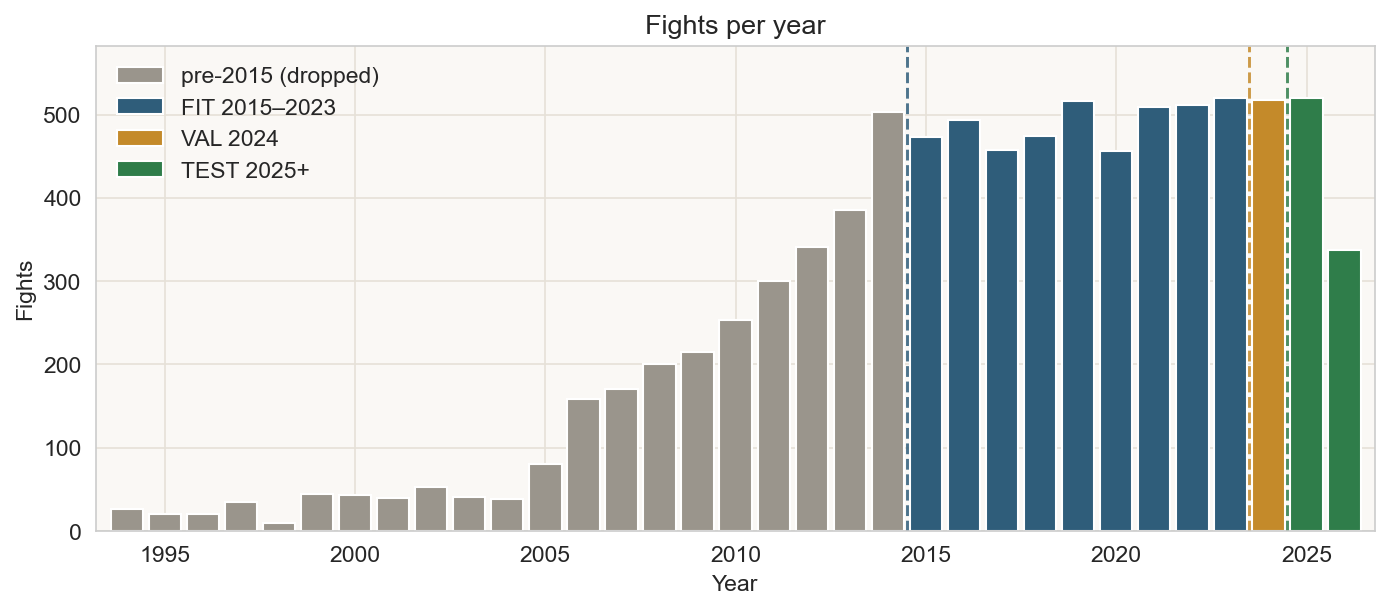

In [3]:
counts = page.groupby("year").size()
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(counts.index, counts.values, color=[era_color(y) for y in counts.index], width=0.85)
for ts, color in ((FIT_START, FIT_C), (VAL_START, VAL_C), (TEST_START, TEST_C)):
    ax.axvline(pd.Timestamp(ts).year - 0.5, color=color, lw=1.4, ls="--", alpha=0.85)

from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(facecolor=PRE_C, label="pre-2015 (dropped)"),
        Patch(facecolor=FIT_C, label="FIT 2015–2023"),
        Patch(facecolor=VAL_C, label="VAL 2024"),
        Patch(facecolor=TEST_C, label="TEST 2025+"),
    ],
    frameon=False,
    loc="upper left",
)
ax.set_xlabel("Year")
ax.set_ylabel("Fights")
ax.set_title("Fights per year")
ax.set_xlim(counts.index.min() - 0.8, counts.index.max() + 0.8)
ax.set_ylim(0, counts.max() * 1.12)
save_fig(fig, "01_fights_per_year")


## 2. Page-order leak

`y_a_win` on the **page** row is “did UFCStats fighter1 win?” Swapped-only is the complement of that line, not 50%. Pooling **page + swapped** is what pins slot-A win rate at 50% — that is why `fight_model_train` has two rows per fight.

What to look for: a flat 100% page line through 2009. If that ever comes back in a recent year, the scraper is listing winners first again. Combined should sit on 0.5 in every year that has a winner.


saved notebooks/figures/02_page_order_leak.png


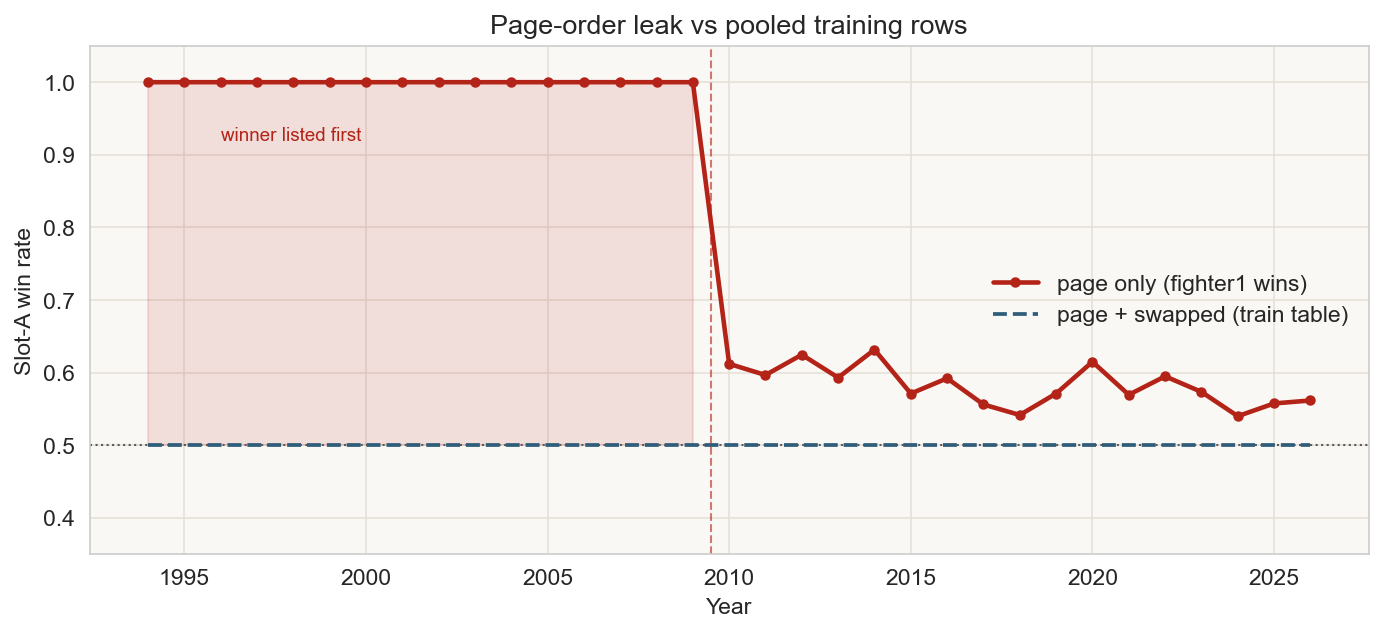

page win rate pre-2010: 1.0
page win rate 2015+: 0.5703011872967719
combined 2015+: 0.5


In [4]:
def win_rate_by_year(frame):
    labeled = frame[frame["y_a_win"].notna()].copy()
    labeled["year"] = labeled["event_date"].dt.year.astype(int)
    grouped = labeled.groupby("year")["y_a_win"]
    return grouped.mean(), grouped.size()


page_rate, page_n = win_rate_by_year(train[train["orientation"] == "page"])
combined_rate, _ = win_rate_by_year(train)

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.axhline(0.5, color=MUTED, lw=1, ls=":")
ax.plot(page_rate.index, page_rate.values, color=LEAK_C, lw=2.2, marker="o", ms=4, label="page only (fighter1 wins)")
ax.plot(combined_rate.index, combined_rate.values, color=FIT_C, lw=1.8, ls="--", label="page + swapped (train table)")
ax.fill_between(page_rate.index, page_rate.values, 0.5, where=page_rate.values > 0.7, color=LEAK_C, alpha=0.12)
ax.axvline(2009.5, color=LEAK_C, lw=1, ls="--", alpha=0.6)
ax.text(1996, 0.92, "winner listed first", color=LEAK_C, fontsize=9)
ax.set_ylim(0.35, 1.05)
ax.set_xlabel("Year")
ax.set_ylabel("Slot-A win rate")
ax.set_title("Page-order leak vs pooled training rows")
ax.legend(frameon=False, loc="center right")
save_fig(fig, "02_page_order_leak")
print("page win rate pre-2010:", float(page_rate[page_rate.index < 2010].mean()))
print("page win rate 2015+:", float(page_rate[page_rate.index >= 2015].mean()))
print("combined 2015+:", float(combined_rate[combined_rate.index >= 2015].mean()))


## 3. Missingness by year

Percent of **page** rows where the column is NULL. Debut rate is plotted as its own row (share of fights where slot A is a UFC debut), not as NULLs.

What to look for: a column that is empty in 2023–2026 but filled in 2018 is a scraper/join hole, not “the sport changed.” Distance cardio is *supposed* to be sparse — it is only defined on fights that went the distance.


saved notebooks/figures/03_missingness.png


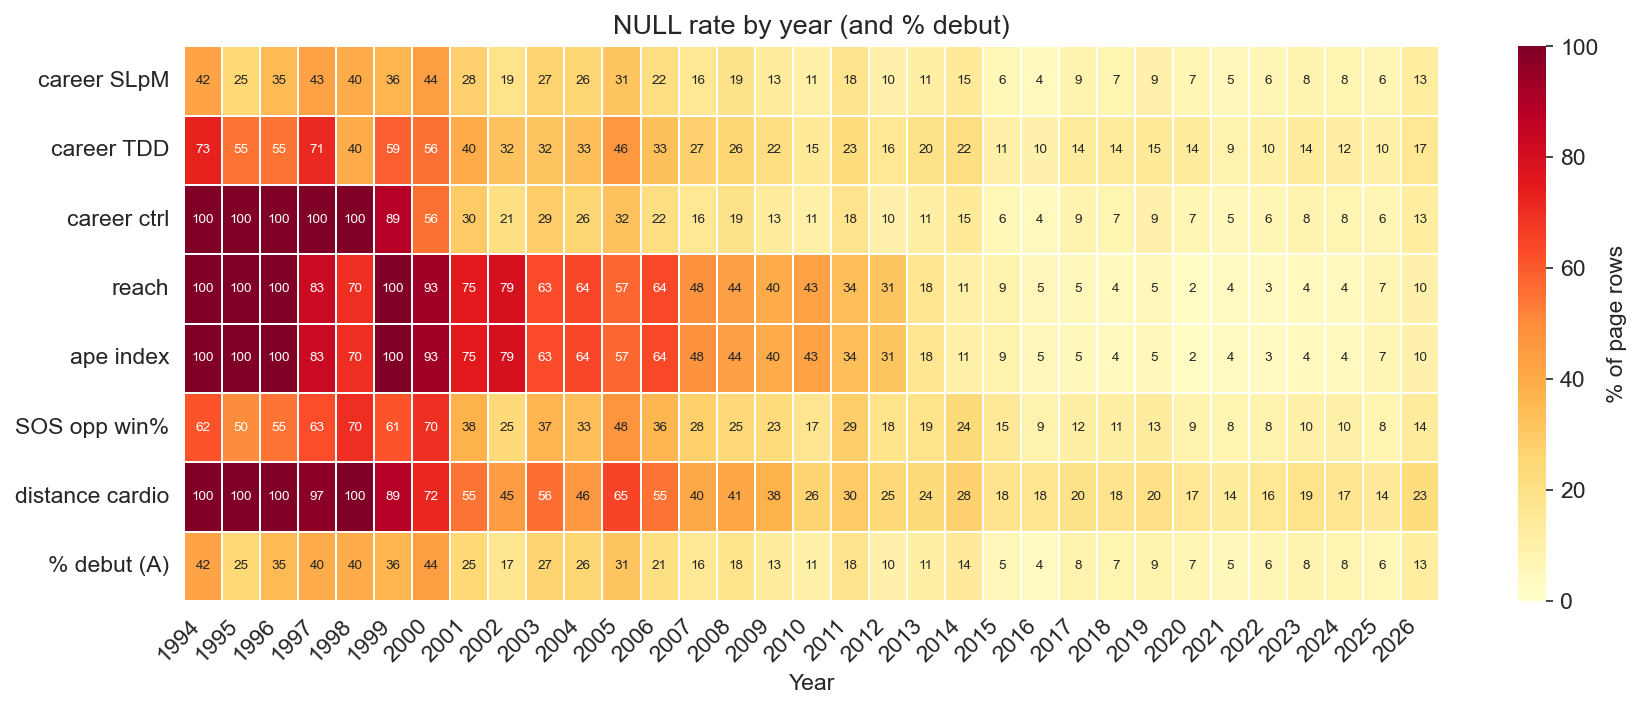

career SLpM        18.8
career TDD         28.6
career ctrl        30.5
reach              41.8
ape index          41.8
SOS opp win%       29.0
distance cardio    43.9
% debut (A)        18.4


In [5]:
MISS = [
    ("a_career_sig_str_landed_pm_avg", "career SLpM"),
    ("a_career_td_defense_avg", "career TDD"),
    ("a_career_ctrl_seconds_avg", "career ctrl"),
    ("a_reach", "reach"),
    ("a_ape_index", "ape index"),
    ("a_career_avg_opp_win_pct", "SOS opp win%"),
    ("a_career_cardio_distance_att_avg", "distance cardio"),
]

heat_rows = {}
for col, label in MISS:
    if col not in page.columns:
        print("skip missing column:", col)
        continue
    heat_rows[label] = 100.0 * page.groupby("year")[col].apply(lambda s: s.isna().mean())
heat_rows["% debut (A)"] = 100.0 * page.groupby("year")["a_debut_flag"].mean()
heat = pd.DataFrame(heat_rows).T
heat = heat.reindex(sorted(heat.columns), axis=1)

fig, ax = plt.subplots(figsize=(13.5, 4.8))
sns.heatmap(
    heat,
    ax=ax,
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    annot=True,
    fmt=".0f",
    annot_kws={"size": 6.5},
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "% of page rows"},
)
ax.set_xlabel("Year")
ax.set_ylabel("")
ax.set_title("NULL rate by year (and % debut)")
plt.xticks(rotation=45, ha="right")
save_fig(fig, "03_missingness")
print(heat.mean(axis=1).round(1).to_string())


## 4. Career vs last-5 SLpM

Page rows, 2015+, non-debut, and **not** using the career fallback for last-5 (those would sit on the diagonal by construction).

Points on the diagonal: last-5 is just career. Off-diagonal color split: recent form is real and it correlates with winning. Axes clip to the 99th percentile so a few 30-second-fight rate explosions don’t flatten the cloud. The ablation file already suggested last-5 is noisy — this scatter is how you see whether that is a TEST fluke or the cloud really is a blob.


saved notebooks/figures/04_career_vs_last5_slpm.png


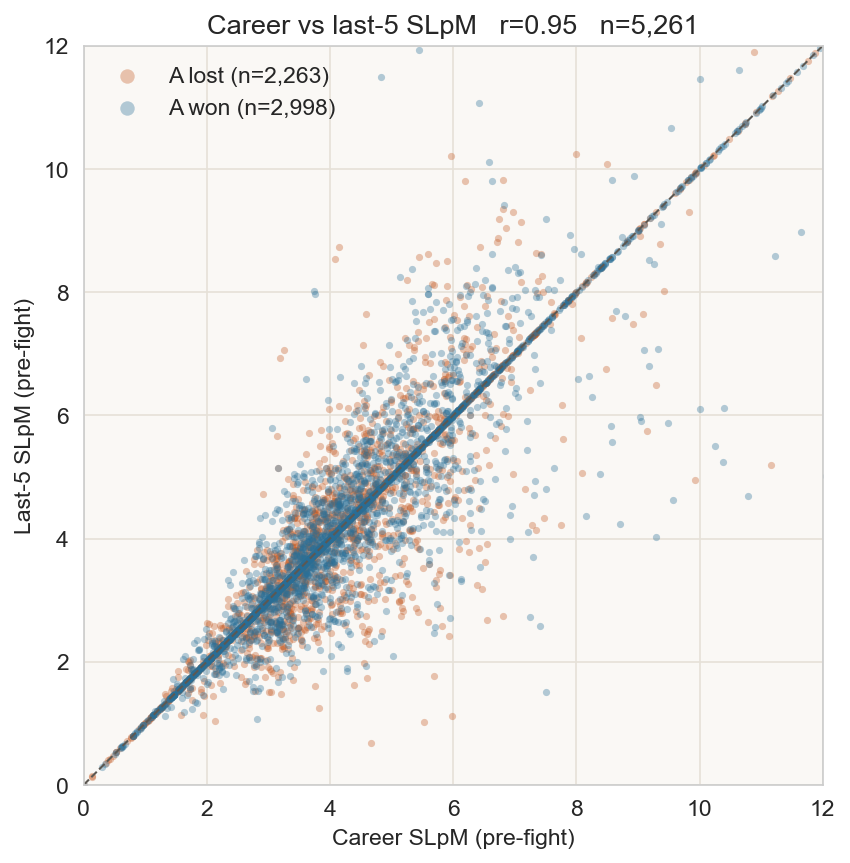

In [6]:
scatter = since_2015.copy()
scatter = scatter[~scatter["a_debut_flag"]]
if "a_used_career_fallback_last5" in scatter.columns:
    scatter = scatter[~scatter["a_used_career_fallback_last5"]]
scatter = scatter[
    scatter["a_career_sig_str_landed_pm_avg"].notna()
    & scatter["a_last5_sig_str_landed_pm_avg"].notna()
    & scatter["y_a_win"].notna()
].copy()
scatter["won"] = scatter["y_a_win"].astype(int).map({1: "A won", 0: "A lost"})

fig, ax = plt.subplots(figsize=(6.8, 6.4))
for label, color in (("A lost", LOSS_C), ("A won", WIN_C)):
    part = scatter[scatter["won"] == label]
    ax.scatter(
        part["a_career_sig_str_landed_pm_avg"],
        part["a_last5_sig_str_landed_pm_avg"],
        s=12,
        alpha=0.35,
        c=color,
        label=f"{label} (n={len(part):,})",
        linewidths=0,
    )
hi = float(np.nanpercentile(
    np.concatenate([
        scatter["a_career_sig_str_landed_pm_avg"].to_numpy(),
        scatter["a_last5_sig_str_landed_pm_avg"].to_numpy(),
    ]),
    99,
))
hi = min(max(hi, 8.0), 12.0)
lims = np.array([0.0, hi])
ax.plot(lims, lims, color=MUTED, lw=1, ls="--")
corr = scatter["a_career_sig_str_landed_pm_avg"].corr(scatter["a_last5_sig_str_landed_pm_avg"])
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Career SLpM (pre-fight)")
ax.set_ylabel("Last-5 SLpM (pre-fight)")
ax.set_title(f"Career vs last-5 SLpM   r={corr:.2f}   n={len(scatter):,}")
ax.legend(frameon=False, loc="upper left", markerscale=2)
save_fig(fig, "04_career_vs_last5_slpm")


## 5. Expected TD product vs actual TD

`prod_expected_td_pm` is career TD attempts per minute × (1 − opponent career TD defense / 100). If this product is doing work, the cloud should slope up. A blob means the extra matchup columns are not buying a takedown model — which is what `add_td_products` in the ablation already hinted.


saved notebooks/figures/05_expected_td_vs_actual.png


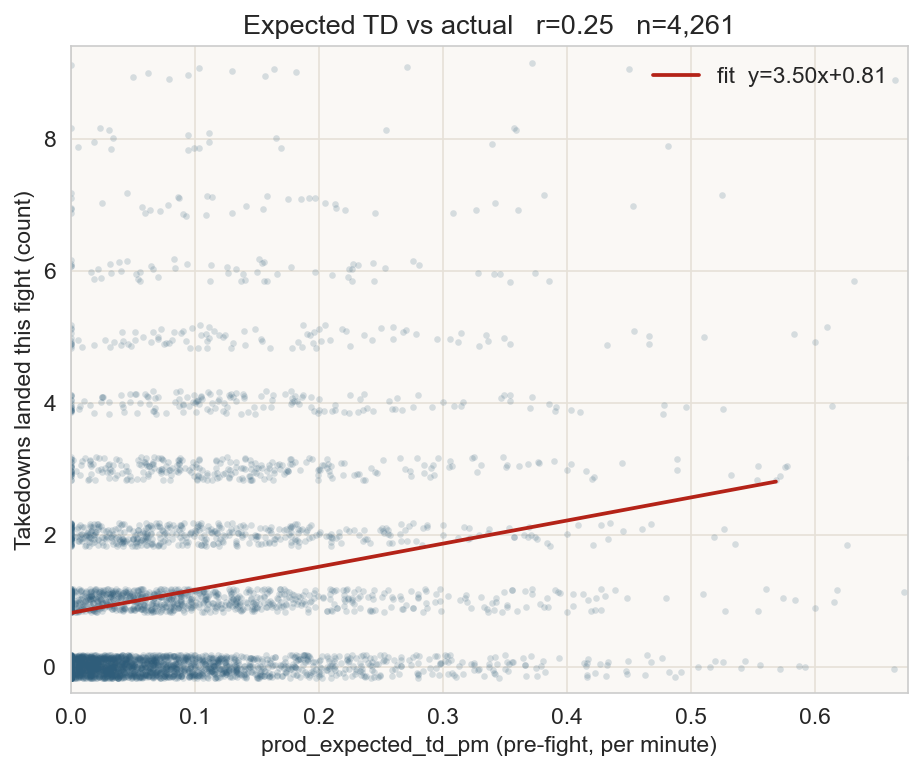

In [7]:
td = since_2015[
    since_2015["prod_expected_td_pm"].notna() & since_2015["y_a_td_landed"].notna()
].copy()
x = td["prod_expected_td_pm"].to_numpy(dtype=float)
y = td["y_a_td_landed"].to_numpy(dtype=float)
mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]
rng = np.random.default_rng(0)
y_jit = y + rng.uniform(-0.18, 0.18, size=len(y))
slope, intercept = np.polyfit(x, y, 1)
r = pd.Series(x).corr(pd.Series(y))

fig, ax = plt.subplots(figsize=(7.2, 5.6))
ax.scatter(x, y_jit, s=10, alpha=0.18, c=FIT_C, linewidths=0)
xs = np.linspace(np.nanpercentile(x, 1), np.nanpercentile(x, 99), 50)
ax.plot(xs, slope * xs + intercept, color=LEAK_C, lw=1.8, label=f"fit  y={slope:.2f}x+{intercept:.2f}")
ax.set_xlabel("prod_expected_td_pm (pre-fight, per minute)")
ax.set_ylabel("Takedowns landed this fight (count)")
ax.set_title(f"Expected TD vs actual   r={r:.2f}   n={len(x):,}")
ax.legend(frameon=False, loc="upper right")
ax.set_xlim(0, np.nanpercentile(x, 99.5))
ax.set_ylim(-0.4, np.nanpercentile(y, 99.5) + 0.4)
save_fig(fig, "05_expected_td_vs_actual")


## 6. Win calibration on TEST

Page orientation, 2025+, labeled fights only. Left: reliability (mean predicted vs actual A-win rate). Right: how often the model is that confident.

What to look for: points on the diagonal. A 58% accurate model is still useful if the 66%+ bucket really wins ~66% of the time. TEST is scored on **page** orientation (same as `train_baseline.py`), so the actual A-win rate is still a bit above 50% — that pulls points above the line. Coin-flip logloss is 0.693.


saved notebooks/figures/06_win_calibration.png


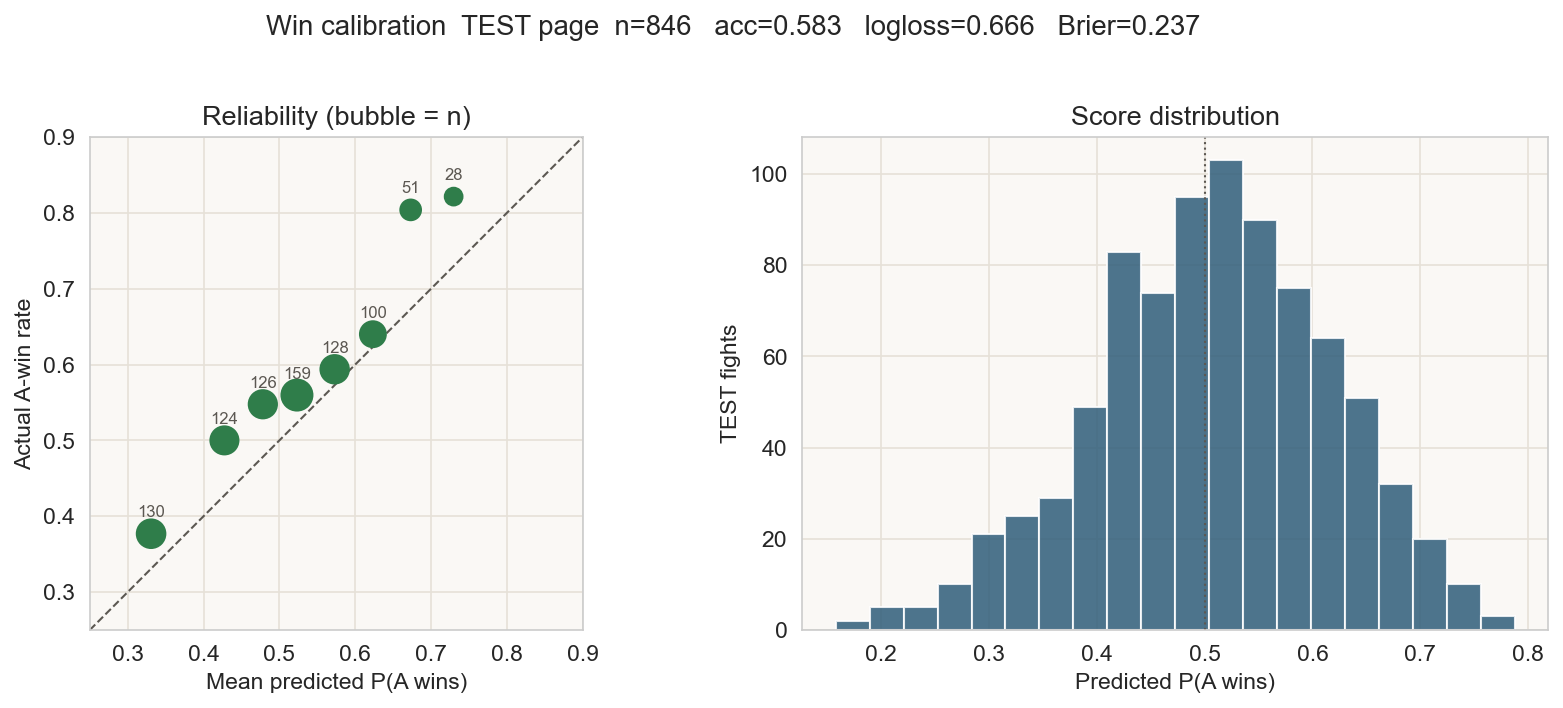

        bin   lo  mean_pred   actual   n
[0.00,0.40) 0.00   0.330802 0.376923 130
[0.40,0.45) 0.40   0.427505 0.500000 124
[0.45,0.50) 0.45   0.478165 0.547619 126
[0.50,0.55) 0.50   0.523140 0.559748 159
[0.55,0.60) 0.55   0.572840 0.593750 128
[0.60,0.65) 0.60   0.623279 0.640000 100
[0.65,0.70) 0.65   0.673078 0.803922  51
[0.70,0.80) 0.70   0.729733 0.821429  28


In [8]:
cal = test_page[test_page["y_a_win"].notna()].copy()
y = cal["y_a_win"].astype(int).to_numpy()
p = np.clip(cal["p_a"].to_numpy(dtype=float), 1e-6, 1 - 1e-6)
pred_hat = (p >= 0.5).astype(int)

edges = [0.0, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.8, 1.01]
rows = []
for lo, hi in zip(edges, edges[1:]):
    mask = (p >= lo) & (p < hi)
    n = int(mask.sum())
    if n == 0:
        continue
    rows.append(
        {
            "bin": f"[{lo:.2f},{hi:.2f})",
            "lo": lo,
            "mean_pred": float(p[mask].mean()),
            "actual": float(y[mask].mean()),
            "n": n,
        }
    )
bins = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))
ax = axes[0]
ax.plot([0.25, 0.90], [0.25, 0.90], color=MUTED, ls="--", lw=1)
sizes = 40 + 180 * (bins["n"] / bins["n"].max())
ax.scatter(bins["mean_pred"], bins["actual"], s=sizes, c=TEST_C, zorder=3)
for _, row in bins.iterrows():
    ax.annotate(
        str(int(row["n"])),
        (row["mean_pred"], row["actual"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8,
        color=MUTED,
    )
ax.set_xlim(0.25, 0.90)
ax.set_ylim(0.25, 0.90)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Mean predicted P(A wins)")
ax.set_ylabel("Actual A-win rate")
ax.set_title("Reliability (bubble = n)")

ax = axes[1]
ax.hist(p, bins=20, color=FIT_C, alpha=0.85, edgecolor="white")
ax.axvline(0.5, color=MUTED, ls=":", lw=1)
ax.set_xlabel("Predicted P(A wins)")
ax.set_ylabel("TEST fights")
ax.set_title("Score distribution")

ll = log_loss(y, p)
acc = accuracy_score(y, pred_hat)
brier = brier_score_loss(y, p)
fig.suptitle(
    f"Win calibration  TEST page  n={len(y)}   acc={acc:.3f}   logloss={ll:.3f}   Brier={brier:.3f}",
    y=1.02,
)
fig.tight_layout()
save_fig(fig, "06_win_calibration")
print(bins.to_string(index=False))


## 7. Predicted vs actual fight shape on TEST

x is the production stat model (same stacked values the win model sees). y is this-fight actual. The dashed line is y = x. Subtitle MAE vs the career-average baseline the training script uses.

What to look for: SLpM should tighten vs career. Control may look like a cloud — on the last train run it did **not** beat its career-average baseline. That is the chart that decides whether stacking ctrl into win is signal or noise.


saved notebooks/figures/07_pred_vs_actual_shape.png


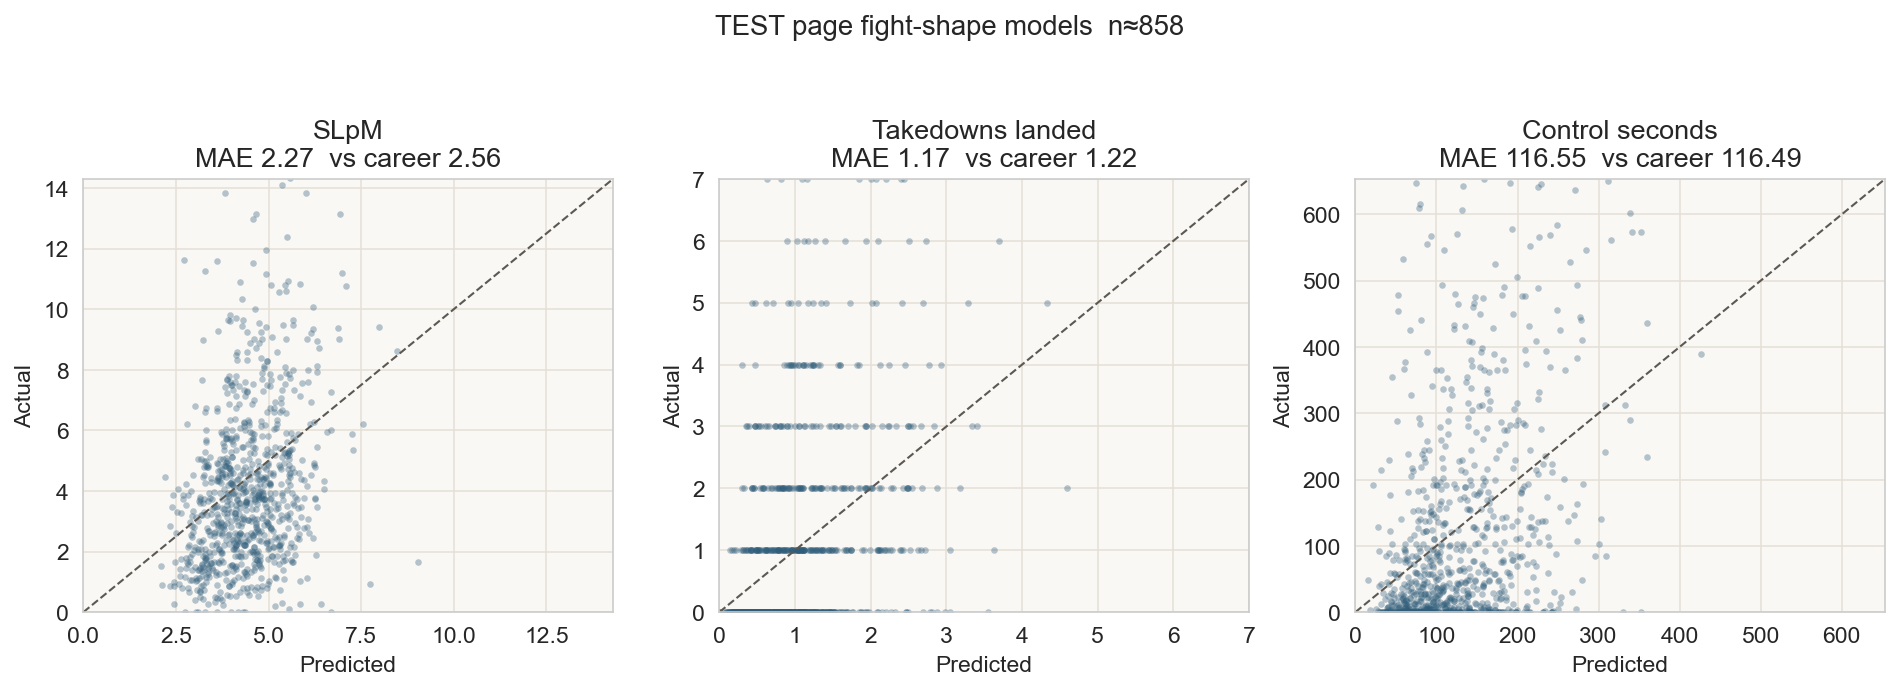

In [9]:
PANELS = [
    ("stack_a_slpm", "y_a_sig_str_landed_pm", "a_career_sig_str_landed_pm_avg", "SLpM", None),
    ("stack_a_td", "y_a_td_landed", "a_career_td_landed_avg", "Takedowns landed", 0.0),
    ("stack_a_ctrl", "y_a_ctrl_seconds", "a_career_ctrl_seconds_avg", "Control seconds", 0.0),
]

fig, axes = plt.subplots(1, 3, figsize=(12.8, 4.4))
for ax, (pred_col, y_col, base_col, title, floor) in zip(axes, PANELS):
    sub = test_page[test_page[pred_col].notna() & test_page[y_col].notna()].copy()
    hat = sub[pred_col].to_numpy(dtype=float)
    actual = sub[y_col].to_numpy(dtype=float)
    if floor is not None:
        hat = np.maximum(hat, floor)
    mae = mean_absolute_error(actual, hat)
    fill = float(np.nanmedian(pd.to_numeric(sub[base_col], errors="coerce"))) if base_col in sub.columns else float(np.nanmedian(actual))
    base = pd.to_numeric(sub[base_col], errors="coerce").fillna(fill) if base_col in sub.columns else np.full(len(actual), fill)
    base_mae = mean_absolute_error(actual, base)
    ax.scatter(hat, actual, s=10, alpha=0.35, c=FIT_C, linewidths=0)
    hi = np.nanpercentile(np.concatenate([hat, actual]), 99)
    lo = min(np.nanmin(hat), np.nanmin(actual))
    lo = min(lo, 0)
    ax.plot([lo, hi], [lo, hi], color=MUTED, ls="--", lw=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(f"{title}\nMAE {mae:.2f}  vs career {base_mae:.2f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
fig.suptitle(f"TEST page fight-shape models  n≈{len(test_page):,}", y=1.04)
fig.tight_layout()
save_fig(fig, "07_pred_vs_actual_shape")


## 8. Ablation: which families earn their keep

From `Models/artifacts/ablate_win_groups.csv`. VAL was used to stop trees, so rank families on VAL logloss; TEST is the exam. Bars to the left of the baseline (logloss) or to the right (accuracy) are *better* than the stacked win recipe.

What to look for: dropping last-5 / cardio / momentum *raising* TEST accuracy. That is a sign those windows are correlated noise on this era, not that you should blindly delete them — freeze the recipe on VAL, then quote TEST once.


saved notebooks/figures/08_ablation.png


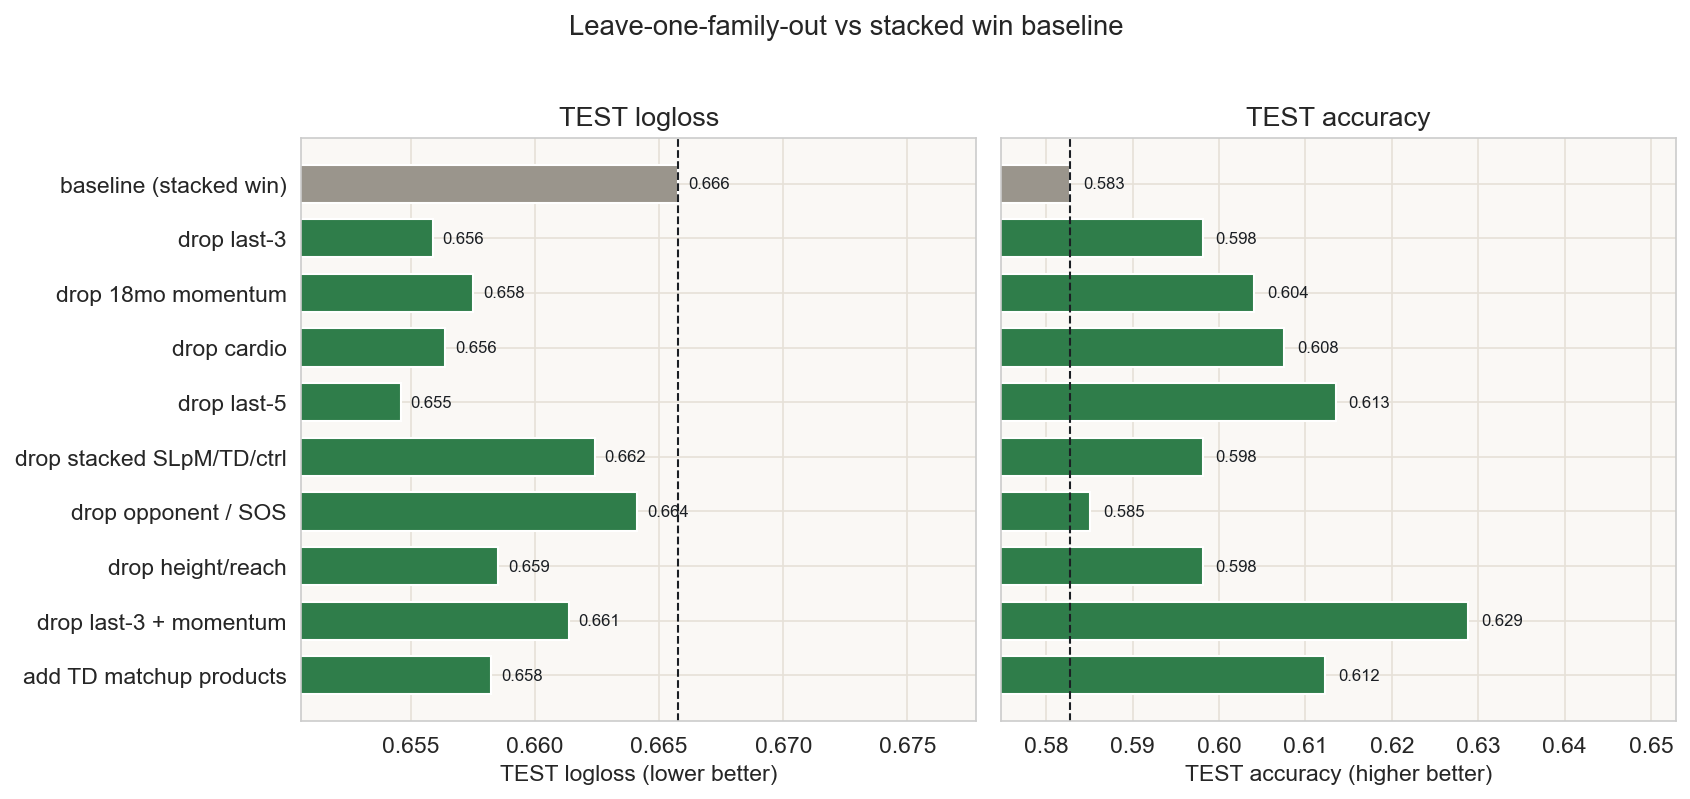

                    label  n_features  val_logloss  val_acc  test_logloss  test_acc
   baseline (stacked win)         670     0.647460 0.629630      0.665767  0.582742
              drop last-3         520     0.650511 0.614035      0.655885  0.598109
       drop 18mo momentum         597     0.648689 0.606238      0.657510  0.604019
              drop cardio         593     0.648906 0.631579      0.656381  0.607565
              drop last-5         453     0.647625 0.629630      0.654590  0.613475
drop stacked SLpM/TD/ctrl         661     0.646834 0.614035      0.662403  0.598109
      drop opponent / SOS         630     0.649497 0.606238      0.664116  0.585106
        drop height/reach         661     0.650859 0.649123      0.658514  0.598109
   drop last-3 + momentum         447     0.657023 0.627680      0.661358  0.628842
  add TD matchup products         674     0.652705 0.612086      0.658242  0.612293


In [10]:
ablate_path = Path(ARTIFACT_DIR) / "ablate_win_groups.csv"
ablate = pd.read_csv(ablate_path)
ablate.columns = [c.strip() for c in ablate.columns]
for col in ablate.columns:
    if col != "recipe":
        ablate[col] = pd.to_numeric(ablate[col], errors="ignore")

labels = {
    "baseline": "baseline (stacked win)",
    "drop_last3": "drop last-3",
    "drop_momentum": "drop 18mo momentum",
    "drop_cardio": "drop cardio",
    "drop_last5": "drop last-5",
    "drop_stack": "drop stacked SLpM/TD/ctrl",
    "drop_opp_sos": "drop opponent / SOS",
    "drop_bio": "drop height/reach",
    "drop_last3+momentum (223 gone)": "drop last-3 + momentum",
    "add_td_products (+4)": "add TD matchup products",
}
ablate["label"] = ablate["recipe"].map(lambda r: labels.get(r, r))
base = ablate[ablate["recipe"] == "baseline"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(11.4, 5.2), sharey=True)
order = list(ablate["label"])
ypos = np.arange(len(order))

ax = axes[0]
ll = ablate["test_logloss"].to_numpy(dtype=float)
colors = [
    PRE_C if abs(r - base["test_logloss"]) < 1e-12 else (TEST_C if r < base["test_logloss"] else LOSS_C)
    for r in ll
]
ax.barh(ypos, ll, color=colors, height=0.7)
ax.axvline(base["test_logloss"], color=INK, lw=1, ls="--")
for y_i, val in zip(ypos, ll):
    ax.text(val + 0.0004, y_i, f"{val:.3f}", va="center", fontsize=8, color=INK)
pad = 0.004
ax.set_xlim(ll.min() - pad, ll.max() + pad * 3)
ax.set_xlabel("TEST logloss (lower better)")
ax.set_yticks(ypos)
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_title("TEST logloss")

ax = axes[1]
acc = ablate["test_acc"].to_numpy(dtype=float)
colors = [
    PRE_C if abs(r - base["test_acc"]) < 1e-12 else (TEST_C if r > base["test_acc"] else LOSS_C)
    for r in acc
]
ax.barh(ypos, acc, color=colors, height=0.7)
ax.axvline(base["test_acc"], color=INK, lw=1, ls="--")
for y_i, val in zip(ypos, acc):
    ax.text(val + 0.0015, y_i, f"{val:.3f}", va="center", fontsize=8, color=INK)
pad_acc = 0.008
ax.set_xlim(acc.min() - pad_acc, acc.max() + pad_acc * 3)
ax.set_xlabel("TEST accuracy (higher better)")
ax.set_title("TEST accuracy")

fig.suptitle("Leave-one-family-out vs stacked win baseline", y=1.02)
fig.tight_layout()
save_fig(fig, "08_ablation")
show = ablate[["label", "n_features", "val_logloss", "val_acc", "test_logloss", "test_acc"]].copy()
print(show.to_string(index=False))
